<a href="https://colab.research.google.com/github/JGaldeano96/TFM-Pedestrian-Traffic-Light/blob/develop/notebooks/CNN_test.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Librerías

In [46]:

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)



from PIL import Image
import math

# VALIDATION ANALYSIS

In [47]:
from pathlib import Path
import pandas as pd


ROOT_DIR = Path.cwd().parent


V1_PATH = (
    ROOT_DIR
    / "results"
    / "classifier"
    / "dataset_v1"
    / "classifier_v1"
    / "predictions_dataset_v1.csv"
)


V2_PATH = (
    ROOT_DIR
    / "results"
    / "classifier"
    / "dataset_v2"
    / "classifier_v2"
    / "predictions_dataset_v2.csv"
)


df_v1 = pd.read_csv(
    V1_PATH
)


df_v2 = pd.read_csv(
    V2_PATH
)


df_v1["dataset"] = "dataset_v1"


df_v2["dataset"] = "dataset_v2"


df = pd.concat(
    [
        df_v1,
        df_v2,
    ],
    ignore_index=True,
)


df

,filename,filepath,true_label,true_class,predicted_label,predicted_class,probability_green,threshold,error_type,dataset
0,000002_frame000001_tdWqnzsoW5.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.988784,0.5,correct,dataset_v1
1,000002_frame000002_gAfLmaPpQX.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.989176,0.5,correct,dataset_v1
2,000002_frame000003_rYdAr2L_qh.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.924877,0.5,correct,dataset_v1
3,000002_frame000004_T-MZ98wc_M.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.986626,0.5,correct,dataset_v1
4,000002_frame000005_k2-TrHuyer.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,1,Green,1,Green,0.987089,0.5,correct,dataset_v1
...,...,...,...,...,...,...,...,...,...,...
2922,000110_frame000012_Ywgr1CqQ4L.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000801,0.5,correct,dataset_v2
2923,000110_frame000013_LnMZTlt1sY.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.001353,0.5,correct,dataset_v2
2924,000110_frame000013_xnGsoIhg0o.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000503,0.5,correct,dataset_v2
2925,000110_frame000014_8SZBiczhPb.jpg,/home/jgaldeano/tfm/data/datasets/classifier/v...,0,Red,0,Red,0.000644,0.5,correct,dataset_v2


In [48]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


# ============================================================
# THRESHOLDS
# ============================================================

THRESHOLD_V1 = 0.046506

THRESHOLD_V2 = 0.8


# ============================================================
# FUNCIÓN DE MÉTRICAS
# ============================================================

def calculate_metrics(
    df_dataset: pd.DataFrame,
    threshold: float,
    dataset_name: str,
) -> dict:

    # --------------------------------------------------------
    # Etiquetas reales
    # --------------------------------------------------------

    y_true = df_dataset[
        "true_label"
    ].to_numpy()

    # --------------------------------------------------------
    # Probabilidad de Green
    # --------------------------------------------------------

    y_scores = df_dataset[
        "probability_green"
    ].to_numpy()

    # --------------------------------------------------------
    # Predicción
    #
    # 0 -> Red
    # 1 -> Green
    # --------------------------------------------------------

    y_pred = (
        y_scores >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Matriz de confusión
    # --------------------------------------------------------

    TN, FP, FN, TP = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    accuracy = (
        (TP + TN)
        / (TP + TN + FP + FN)
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    false_positive_rate = (
        FP / (FP + TN)
        if (FP + TN) > 0
        else 0
    )

    false_negative_rate = (
        FN / (FN + TP)
        if (FN + TP) > 0
        else 0
    )

    false_green_rate = (
        FP / (FP + TN)
        if (FP + TN) > 0
        else 0
    )

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    roc_auc = roc_auc_score(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Youden
    #
    # Se calcula solamente como referencia.
    # NO determina el threshold utilizado.
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_scores,
    )

    youden_scores = (
        tpr - fpr
    )

    youden_threshold = thresholds[
        np.argmax(youden_scores)
    ]

    # --------------------------------------------------------
    # Resultado
    # --------------------------------------------------------

    return {

        "threshold": threshold,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "specificity": specificity,

        "false_positive_rate": false_positive_rate,

        "false_negative_rate": false_negative_rate,

        "false_green_rate": false_green_rate,

        "TN": TN,

        "FP": FP,

        "FN": FN,

        "TP": TP,

        "roc_auc": roc_auc,

        "youden_threshold": youden_threshold,

        "dataset": dataset_name,

        "num_images": len(df_dataset),
    }


# ============================================================
# CALCULAR MÉTRICAS
# ============================================================

results = []


# ------------------------------------------------------------
# DATASET V1
# ------------------------------------------------------------

df_v1 = df[
    df["dataset"] == "dataset_v1"
]


results.append(
    calculate_metrics(
        df_dataset=df_v1,
        threshold=THRESHOLD_V1,
        dataset_name="dataset_v1",
    )
)


# ------------------------------------------------------------
# DATASET V2
# ------------------------------------------------------------

df_v2 = df[
    df["dataset"] == "dataset_v2"
]


results.append(
    calculate_metrics(
        df_dataset=df_v2,
        threshold=THRESHOLD_V2,
        dataset_name="dataset_v2",
    )
)


# ============================================================
# DATAFRAME FINAL
# ============================================================

metrics_df = pd.DataFrame(
    results
)


metrics_df

,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,num_images
0,0.046506,0.991194,0.997727,0.982103,0.989853,0.998261,0.001739,0.017897,0.001739,574,1,8,439,0.997996,0.046506,dataset_v1,1022
1,0.800000,0.997900,1.000000,0.995134,0.997561,1.000000,0.000000,0.004866,0.000000,1083,0,4,818,0.999978,0.089264,dataset_v2,1905


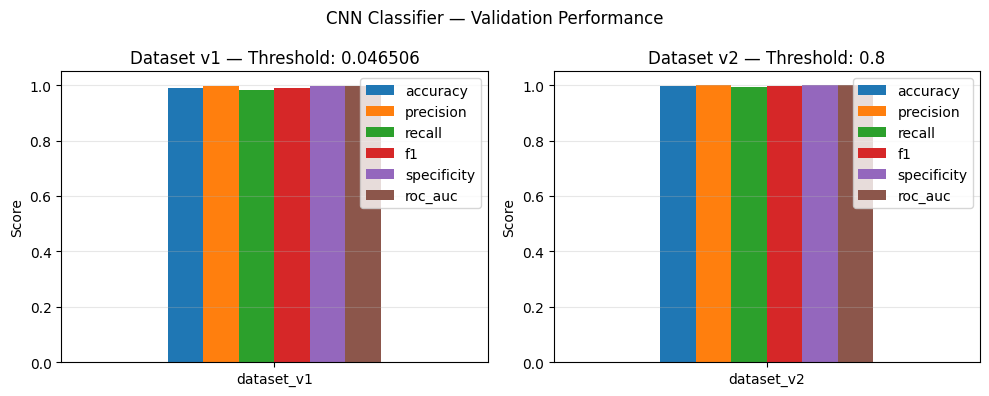

In [49]:
# ============================================================
# GRÁFICOS — MÉTRICAS POR DATASET
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)


# ============================================================
# DATASET V1
# ============================================================

v1_df = metrics_df[
    metrics_df["dataset"] == "dataset_v1"
].set_index("dataset")[metrics]


v1_df.plot(
    kind="bar",
    ax=axes[0],
)


axes[0].set_title(
    f"Dataset v1 — Threshold: {THRESHOLD_V1}"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)

axes[0].tick_params(
    axis="x",
    rotation=0,
)

axes[0].grid(
    axis="y",
    alpha=0.3,
)


# ============================================================
# DATASET V2
# ============================================================

v2_df = metrics_df[
    metrics_df["dataset"] == "dataset_v2"
].set_index("dataset")[metrics]


v2_df.plot(
    kind="bar",
    ax=axes[1],
)


axes[1].set_title(
    f"Dataset v2 — Threshold: {THRESHOLD_V2}"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)

axes[1].tick_params(
    axis="x",
    rotation=0,
)

axes[1].grid(
    axis="y",
    alpha=0.3,
)


# ============================================================
# AJUSTES
# ============================================================

fig.suptitle(
    "CNN Classifier — Validation Performance",
    fontsize=12,
)

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# MÉTRICAS POR THRESHOLD
# ============================================================

threshold_results = []

thresholds = np.round(
    np.arange(
        0.00,
        1.01,
        0.01,
    ),
    2,
)


# ============================================================
# FUNCIÓN
# ============================================================

def calculate_threshold_metrics(
    df_dataset: pd.DataFrame,
    threshold: float,
    dataset_name: str,
) -> dict:

    y_true = df_dataset[
        "true_label"
    ].to_numpy()

    y_scores = df_dataset[
        "probability_green"
    ].to_numpy()

    y_pred = (
        y_scores >= threshold
    ).astype(int)

    TN, FP, FN, TP = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    accuracy = (
        (TP + TN)
        / (TP + TN + FP + FN)
    )

    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP > 0
        else 0
    )

    false_positive_rate = (
        FP / (FP + TN)
        if FP + TN > 0
        else 0
    )

    false_negative_rate = (
        FN / (FN + TP)
        if FN + TP > 0
        else 0
    )

    false_green_rate = false_positive_rate

    return {

        "dataset": dataset_name,

        "threshold": threshold,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "specificity": specificity,

        "false_positive_rate": false_positive_rate,

        "false_negative_rate": false_negative_rate,

        "false_green_rate": false_green_rate,

        "TN": TN,

        "FP": FP,

        "FN": FN,

        "TP": TP,
    }


# ============================================================
# DATASET V1
# ============================================================

df_v1 = df[
    df["dataset"] == "dataset_v1"
]


for threshold in thresholds:

    threshold_results.append(
        calculate_threshold_metrics(
            df_dataset=df_v1,
            threshold=threshold,
            dataset_name="dataset_v1",
        )
    )


# ============================================================
# DATASET V2
# ============================================================

df_v2 = df[
    df["dataset"] == "dataset_v2"
]


for threshold in thresholds:

    threshold_results.append(
        calculate_threshold_metrics(
            df_dataset=df_v2,
            threshold=threshold,
            dataset_name="dataset_v2",
        )
    )


# ============================================================
# DATAFRAME FINAL
# ============================================================

threshold_metrics_df = pd.DataFrame(
    threshold_results
)


threshold_metrics_df.head()

,dataset,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP
0,dataset_v1,0.00,0.437378,0.437378,1.000000,0.608577,0.000000,1.000000,0.000000,1.000000,0,575,0,447
1,dataset_v1,0.01,0.983366,0.967391,0.995526,0.981257,0.973913,0.026087,0.004474,0.026087,560,15,2,445
2,dataset_v1,0.02,0.986301,0.982183,0.986577,0.984375,0.986087,0.013913,0.013423,0.013913,567,8,6,441
3,dataset_v1,0.03,0.989237,0.990991,0.984340,0.987654,0.993043,0.006957,0.015660,0.006957,571,4,7,440
4,dataset_v1,0.04,0.989237,0.993213,0.982103,0.987627,0.994783,0.005217,0.017897,0.005217,572,3,8,439


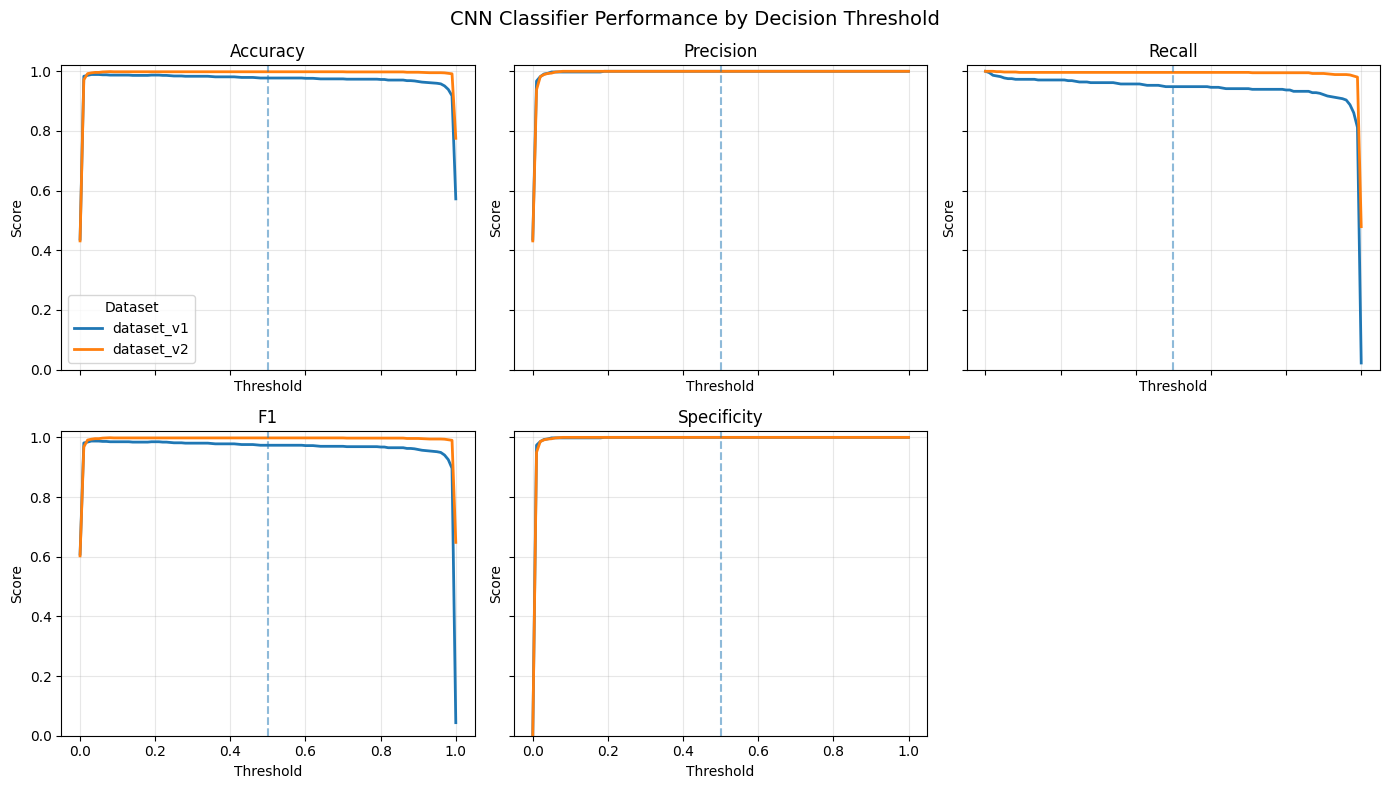

In [51]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
]

datasets = sorted(
    threshold_metrics_df["dataset"].unique()
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 8),
    sharex=True,
    sharey=True,
)


axes = axes.flatten()


# ============================================================
# PLOTS
# ============================================================

for col, metric in enumerate(metrics):

    ax = axes[col]

    for dataset in datasets:

        data = threshold_metrics_df[
            threshold_metrics_df["dataset"] == dataset
        ].sort_values(
            "threshold"
        )

        ax.plot(
            data["threshold"],
            data[metric],
            label=dataset,
            linewidth=2,
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        metric.capitalize()
    )

    ax.set_xlabel(
        "Threshold"
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_ylim(
        0,
        1.02,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Threshold 0.5
    # --------------------------------------------------------

    ax.axvline(
        0.5,
        linestyle="--",
        alpha=0.5,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if col == 0:

        ax.legend(
            title="Dataset"
        )


# ============================================================
# OCULTAR GRÁFICO SOBRANTE
# ============================================================

axes[-1].set_visible(False)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classifier Performance by Decision Threshold",
    fontsize=14,
)

fig.tight_layout()

plt.show()

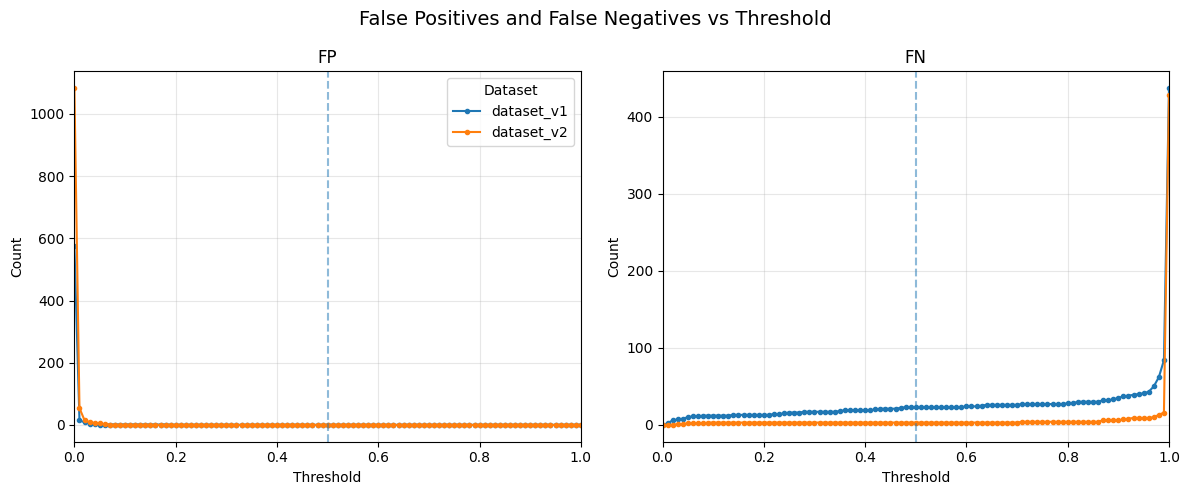

In [52]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "FP",
    "FN",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    sharex=True,
)


# ============================================================
# PLOTS
# ============================================================

for col, metric in enumerate(metrics):

    ax = axes[col]

    for dataset in datasets:

        df_dataset = threshold_metrics_df[
            threshold_metrics_df["dataset"] == dataset
        ].sort_values(
            "threshold"
        )

        ax.plot(
            df_dataset["threshold"],
            df_dataset[metric],
            marker="o",
            markersize=3,
            label=dataset,
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        metric
    )

    ax.set_xlabel(
        "Threshold"
    )

    ax.set_ylabel(
        "Count"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.set_xlim(
        0,
        1,
    )

    # --------------------------------------------------------
    # Threshold 0.5
    # --------------------------------------------------------

    ax.axvline(
        0.5,
        linestyle="--",
        alpha=0.5,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if col == 0:

        ax.legend(
            title="Dataset"
        )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "False Positives and False Negatives vs Threshold",
    fontsize=14,
)

fig.tight_layout()

plt.show()

dataset_v1 Youden threshold: 0.0465
dataset_v2 Youden threshold: 0.0893


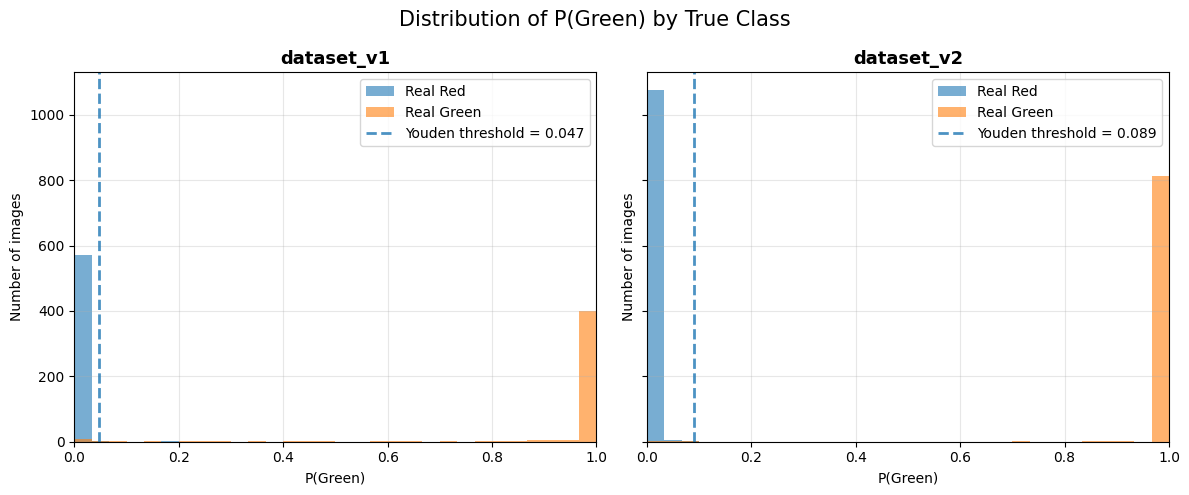

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import roc_curve


# ============================================================
# CONFIGURATION
# ============================================================

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# CALCULATE YOUDEN THRESHOLD
#
# Un único threshold por modelo utilizando todo su dataset.
# ============================================================

thresholds = {}


for dataset in datasets:

    df_dataset = df[
        df["dataset"] == dataset
    ]

    # --------------------------------------------------------
    # True labels
    #
    # Red   -> 0
    # Green -> 1
    # --------------------------------------------------------

    y_true = (
        df_dataset["true_label"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # Model output
    #
    # P(Green)
    # --------------------------------------------------------

    y_scores = (
        df_dataset["probability_green"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # ROC
    # --------------------------------------------------------

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Remove infinite threshold
    # --------------------------------------------------------

    valid = np.isfinite(
        roc_thresholds
    )

    fpr = fpr[valid]
    tpr = tpr[valid]
    roc_thresholds = roc_thresholds[valid]

    # --------------------------------------------------------
    # Youden's J
    #
    # J = TPR - FPR
    # --------------------------------------------------------

    youden = (
        tpr - fpr
    )

    best_index = np.argmax(
        youden
    )

    best_threshold = float(
        roc_thresholds[best_index]
    )

    thresholds[dataset] = (
        best_threshold
    )

    print(
        f"{dataset} Youden threshold: "
        f"{best_threshold:.4f}"
    )


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    sharex=True,
    sharey=True,
)


# ============================================================
# PLOTS
# ============================================================

for ax, dataset in zip(
    axes,
    datasets,
):

    df_dataset = df[
        df["dataset"] == dataset
    ]

    threshold = thresholds[
        dataset
    ]

    # --------------------------------------------------------
    # Real Red
    # --------------------------------------------------------

    red = df_dataset.loc[
        df_dataset["true_class"] == "Red",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Real Green
    # --------------------------------------------------------

    green = df_dataset.loc[
        df_dataset["true_class"] == "Green",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Histograms
    # --------------------------------------------------------

    ax.hist(
        red,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Red",
    )

    ax.hist(
        green,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Green",
    )

    # --------------------------------------------------------
    # Youden threshold
    # --------------------------------------------------------

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=(
            f"Youden threshold = "
            f"{threshold:.3f}"
        ),
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        dataset,
        fontsize=13,
        fontweight="bold",
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_ylabel(
        "Number of images"
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Distribution of P(Green) by True Class",
    fontsize=15,
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

En el dataset_v1 el modelo está obligado a funcionar con thresholds bajos ya que incrementarlo supone asumir muchos falsos negativos. Sin embargo, el modelo con dataset_v2 demuestra una mejora significativa a la hora de separar las dos clases de manera que podemos desplazar el threshold sin que suponga una pérdida de la eficacia ni un exceso de falsos negativos. De hecho hasta 0.7 aproximadamente no aumentaría ninguno.

El problema es que al haber tan pocos errores, el punto de Youden puede volverse inestable y no considero que sea una métrica a tener en cuenta. Es por esta razón que, para el dataset v2 usaremos un threshold más alto para asegurar que el modelo es cauto en la clasificación de semaforos y probablemente quede fijado en alrededor de 0.8.

No obstante, los resultados con el test de validación son muy positivos en ambos modelos aunque claramente la ventaja comentada nos hace inclinarnos sobre el modelo en su segunda versión.

# TEST ANALYSIS

In [54]:
RESULTS_DIR = Path("..") / "results" / "classifier"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [55]:
RESULTS_DIR

PosixPath('../results/classifier')

In [56]:
df = pd.read_csv(RESULTS_DIR
                 /"test"
                 /"cnn_test_metrics.csv")

print(df.columns)
df

Index(['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity',
       'false_positive_rate', 'false_negative_rate', 'false_green_rate', 'TN',
       'FP', 'FN', 'TP', 'roc_auc', 'youden_threshold', 'dataset', 'test_type',
       'model_path', 'num_images'],
      dtype='object')


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,test_type,model_path,num_images
0,0.5,0.871324,1.000000,0.713115,0.832536,1.000000,0.000000,0.286885,0.000000,450,0,105,261,0.998142,0.040779,dataset_v1,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
1,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.994767,dataset_v1,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119
2,0.5,0.992647,0.983871,1.000000,0.991870,0.986667,0.013333,0.000000,0.013333,444,6,0,366,0.999976,0.876833,dataset_v2,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
3,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.999999,dataset_v2,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119


## Análisis comparativo: métricas generales

In [57]:
df = pd.read_csv(RESULTS_DIR
                 /"test"
                 /"cnn_test_metrics.csv")

print(df.columns)
df

Index(['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity',
       'false_positive_rate', 'false_negative_rate', 'false_green_rate', 'TN',
       'FP', 'FN', 'TP', 'roc_auc', 'youden_threshold', 'dataset', 'test_type',
       'model_path', 'num_images'],
      dtype='object')


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP,roc_auc,youden_threshold,dataset,test_type,model_path,num_images
0,0.5,0.871324,1.000000,0.713115,0.832536,1.000000,0.000000,0.286885,0.000000,450,0,105,261,0.998142,0.040779,dataset_v1,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
1,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.994767,dataset_v1,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119
2,0.5,0.992647,0.983871,1.000000,0.991870,0.986667,0.013333,0.000000,0.013333,444,6,0,366,0.999976,0.876833,dataset_v2,diurn,/home/jgaldeano/tfm/results/classifier/dataset...,816
3,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504,1.000000,0.999999,dataset_v2,nocturn,/home/jgaldeano/tfm/results/classifier/dataset...,1119


In [58]:
# ============================================================
# RESUMEN GLOBAL DEL CLASIFICADOR
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]

summary_df = (
    df[
        [
            "dataset",
            "test_type",
            *metrics,
        ]
    ]
    .sort_values(
        ["dataset", "test_type"]
    )
    .reset_index(drop=True)
)

summary_df

,dataset,test_type,accuracy,precision,recall,f1,specificity,roc_auc
0,dataset_v1,diurn,0.871324,1.000000,0.713115,0.832536,1.000000,0.998142
1,dataset_v1,nocturn,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,dataset_v2,diurn,0.992647,0.983871,1.000000,0.991870,0.986667,0.999976
3,dataset_v2,nocturn,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


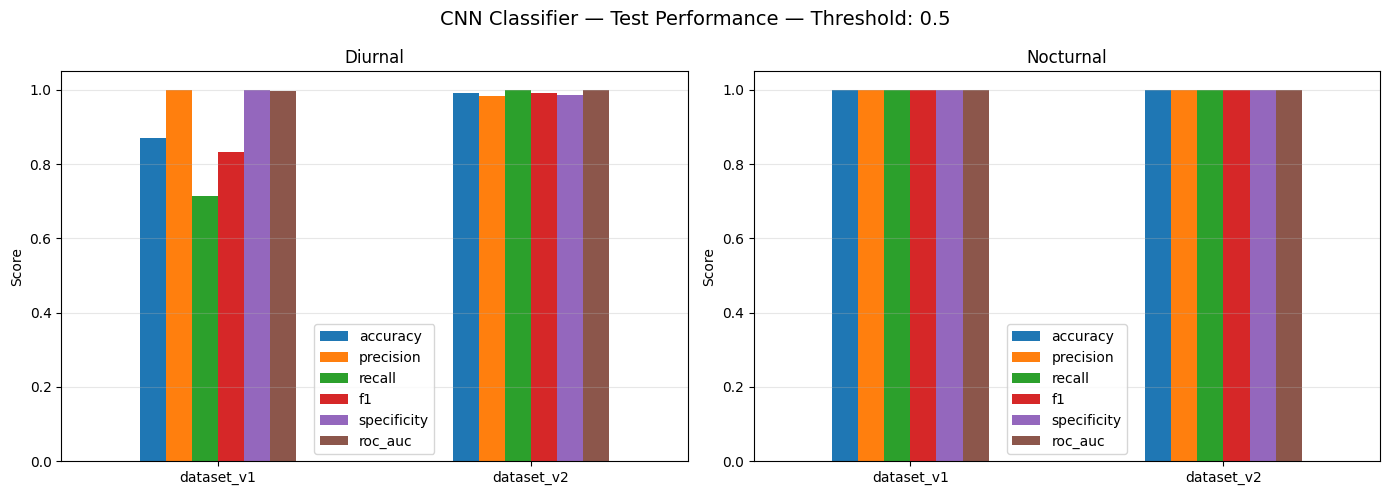

In [59]:
# ============================================================
# GRÁFICO — MÉTRICAS GLOBALES
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "roc_auc",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

# ============================================================
# DIURNO
# ============================================================

diurn_df = summary_df[
    summary_df["test_type"] == "diurn"
].set_index("dataset")[metrics]

diurn_df.plot(
    kind="bar",
    ax=axes[0],
)

axes[0].set_title("Diurnal")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(
    axis="y",
    alpha=0.3,
)

# ============================================================
# NOCTURNO
# ============================================================

nocturn_df = summary_df[
    summary_df["test_type"] == "nocturn"
].set_index("dataset")[metrics]

nocturn_df.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].set_title("Nocturnal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(
    axis="y",
    alpha=0.3,
)

fig.suptitle(
    "CNN Classifier — Test Performance — Threshold: 0.5",
    fontsize=14,
)

plt.tight_layout()
plt.show()

Se observa que en dataset_v1 el recall es considerablemente bajo (que porcentaje de verdes detectamos correctamente) mientras que la specificity es muy elevada (que porcentaje de rojos detectamos correctamente)

La mejora que aporta dataset_v2 es visible en todas las métricas.

In [60]:
df_threshold = pd.read_csv(RESULTS_DIR
                 /"test"
                 /"cnn_test_threshold_metrics.csv")

print(df_threshold.columns)


df_threshold

Index(['dataset', 'test_type', 'threshold', 'accuracy', 'precision', 'recall',
       'f1', 'specificity', 'false_positive_rate', 'false_negative_rate',
       'false_green_rate', 'TN', 'FP', 'FN', 'TP'],
      dtype='object')


,dataset,test_type,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,false_green_rate,TN,FP,FN,TP
0,dataset_v1,diurn,0.00,0.448529,0.448529,1.000000,0.619289,0.000000,1.000000,0.000000,1.000000,0,450,0,366
1,dataset_v1,diurn,0.01,0.964461,0.928753,0.997268,0.961792,0.937778,0.062222,0.002732,0.062222,422,28,1,365
2,dataset_v1,diurn,0.02,0.965686,0.940104,0.986339,0.962667,0.948889,0.051111,0.013661,0.051111,427,23,5,361
3,dataset_v1,diurn,0.03,0.969363,0.947507,0.986339,0.966533,0.955556,0.044444,0.013661,0.044444,430,20,5,361
4,dataset_v1,diurn,0.04,0.977941,0.965241,0.986339,0.975676,0.971111,0.028889,0.013661,0.028889,437,13,5,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,dataset_v2,nocturn,0.96,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
400,dataset_v2,nocturn,0.97,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
401,dataset_v2,nocturn,0.98,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504
402,dataset_v2,nocturn,0.99,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,615,0,0,504


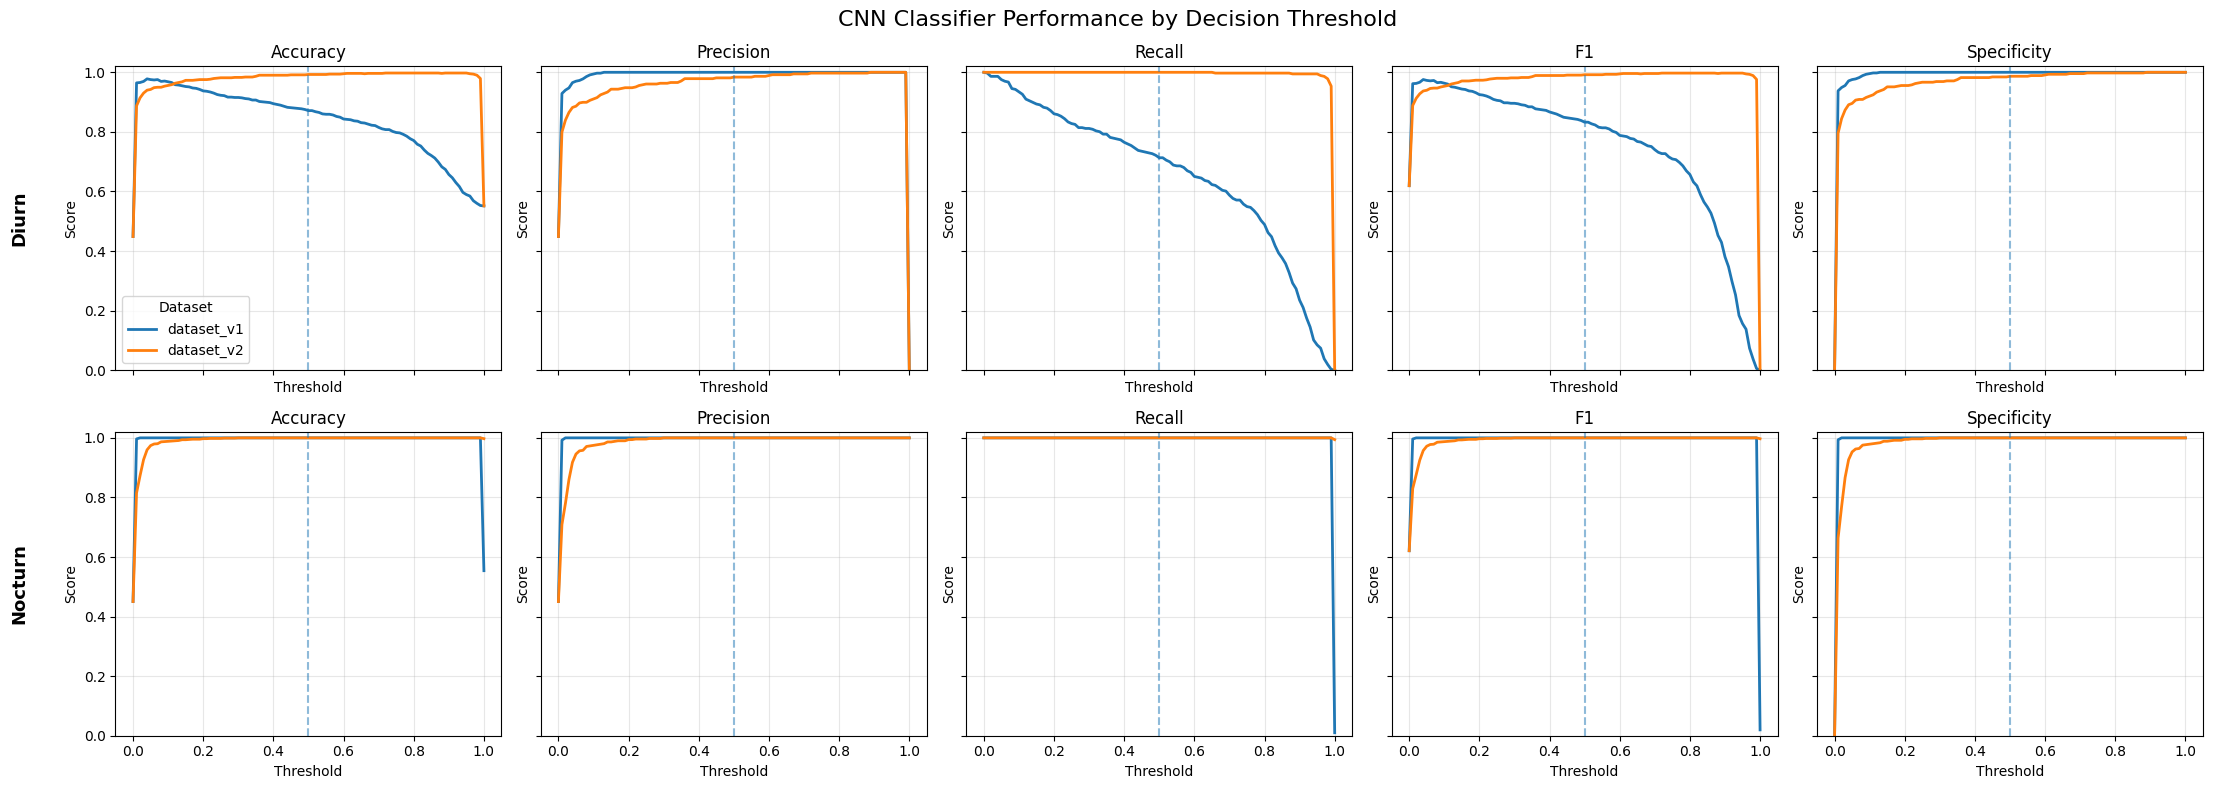

In [61]:
# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = sorted(
    df_threshold["dataset"].unique()
)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 8),
    sharex=True,
    sharey=True,
)

# ============================================================
# PLOTS
# ============================================================

for row, test_type in enumerate(test_types):

    data_test = df_threshold[
        df_threshold["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            data = data_test[
                data_test["dataset"] == dataset
            ]

            ax.plot(
                data["threshold"],
                data[metric],
                label=dataset,
                linewidth=2,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            metric.capitalize()
        )

        ax.set_xlabel(
            "Threshold"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.set_ylim(
            0,
            1.02,
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        # ----------------------------------------------------
        # Threshold 0.5
        # ----------------------------------------------------

        ax.axvline(
            0.5,
            linestyle="--",
            alpha=0.5,
        )

        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        if row == 0 and col == 0:

            ax.legend(
                title="Dataset"
            )


# ============================================================
# ROW LABELS
# ============================================================

axes[0, 0].annotate(
    "Diurn",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold",
)

axes[1, 0].annotate(
    "Nocturn",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold",
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classifier Performance by Decision Threshold",
    fontsize=16,
)

fig.tight_layout()

plt.show()

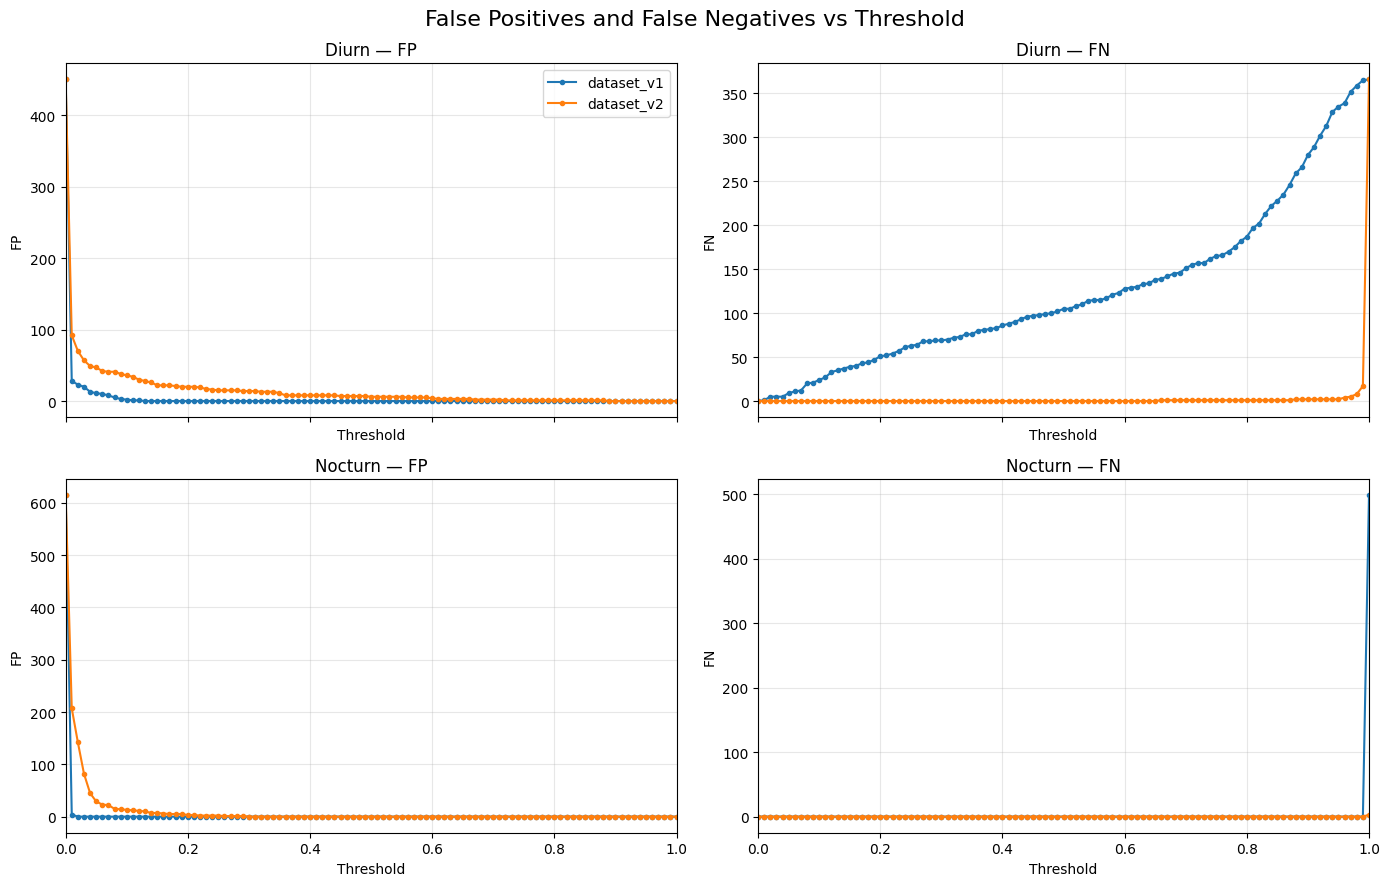

In [62]:
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

metrics = [
    "FP",
    "FN",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
    sharex=True,
)

for row, test_type in enumerate(test_types):

    df_test = df_threshold[
        df_threshold["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            df_dataset = df_test[
                df_test["dataset"] == dataset
            ]

            ax.plot(
                df_dataset["threshold"],
                df_dataset[metric],
                marker="o",
                markersize=3,
                label=dataset,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            f"{test_type.capitalize()} — {metric}"
        )

        ax.set_xlabel(
            "Threshold"
        )

        ax.set_ylabel(
            metric
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.set_xlim(
            0,
            1,
        )

        if row == 0 and col == 0:
            ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "False Positives and False Negatives vs Threshold",
    fontsize=16,
)

plt.tight_layout()

plt.show()

En el modelo entrenado con el dataset v1 se observa un marcado trade-off entre los falsos positivos y los falsos negativos. A medida que aumenta el threshold, el modelo adopta un comportamiento más conservador a la hora de clasificar un semáforo como verde, reduciendo progresivamente los falsos positivos. Sin embargo, esta mejora se produce a costa de un incremento considerable de los falsos negativos, es decir, de semáforos verdes clasificados incorrectamente como rojos.

Por el contrario, el modelo entrenado con el dataset v2 presenta un comportamiento más favorable. Para thresholds bajos, inicialmente genera un mayor número de falsos positivos, lo que implica un mayor riesgo de clasificar como verde un semáforo que realmente se encuentra en rojo. No obstante, este comportamiento se corrige rápidamente al incrementar el threshold. En un rango amplio de valores, el modelo consigue reducir progresivamente los falsos positivos manteniendo simultáneamente los falsos negativos en valores mínimos, llegando incluso a mantener un recall del 100 % en el conjunto diurno durante una amplia región de thresholds.

En el conjunto nocturno, ambos modelos presentan un comportamiento más similar. A partir de un threshold aproximado de 0.2, las diferencias entre ambos se reducen considerablemente y sus resultados tienden a converger. Por debajo de este valor se reproduce el comportamiento observado en el conjunto diurno: los thresholds bajos favorecen la aparición de un mayor número de falsos positivos, aumentando el riesgo de clasificar incorrectamente un semáforo rojo como verde.

Este comportamiento resulta especialmente relevante a la hora de evaluar el riesgo asociado a los errores de clasificación, mostrando el modelo v2 una mayor robustez, ya que permite reducir los falsos positivos sin incrementar los falsos negativos.

## Errores dataset_v1

### Diurno

In [63]:
df_v1_diurn = pd.read_csv(
    RESULTS_DIR
    / "test"
    / "predictions_dataset_v1_diurn.csv"
)

df_errors_diurn = df_v1_diurn[
    df_v1_diurn["error_type"] != "correct"
].copy()

print(
    f"Diurn errors: {len(df_errors_diurn)}"
)

print(
    df_errors_diurn["error_type"].value_counts()
)

Diurn errors: 105
error_type
FN    105
Name: count, dtype: int64


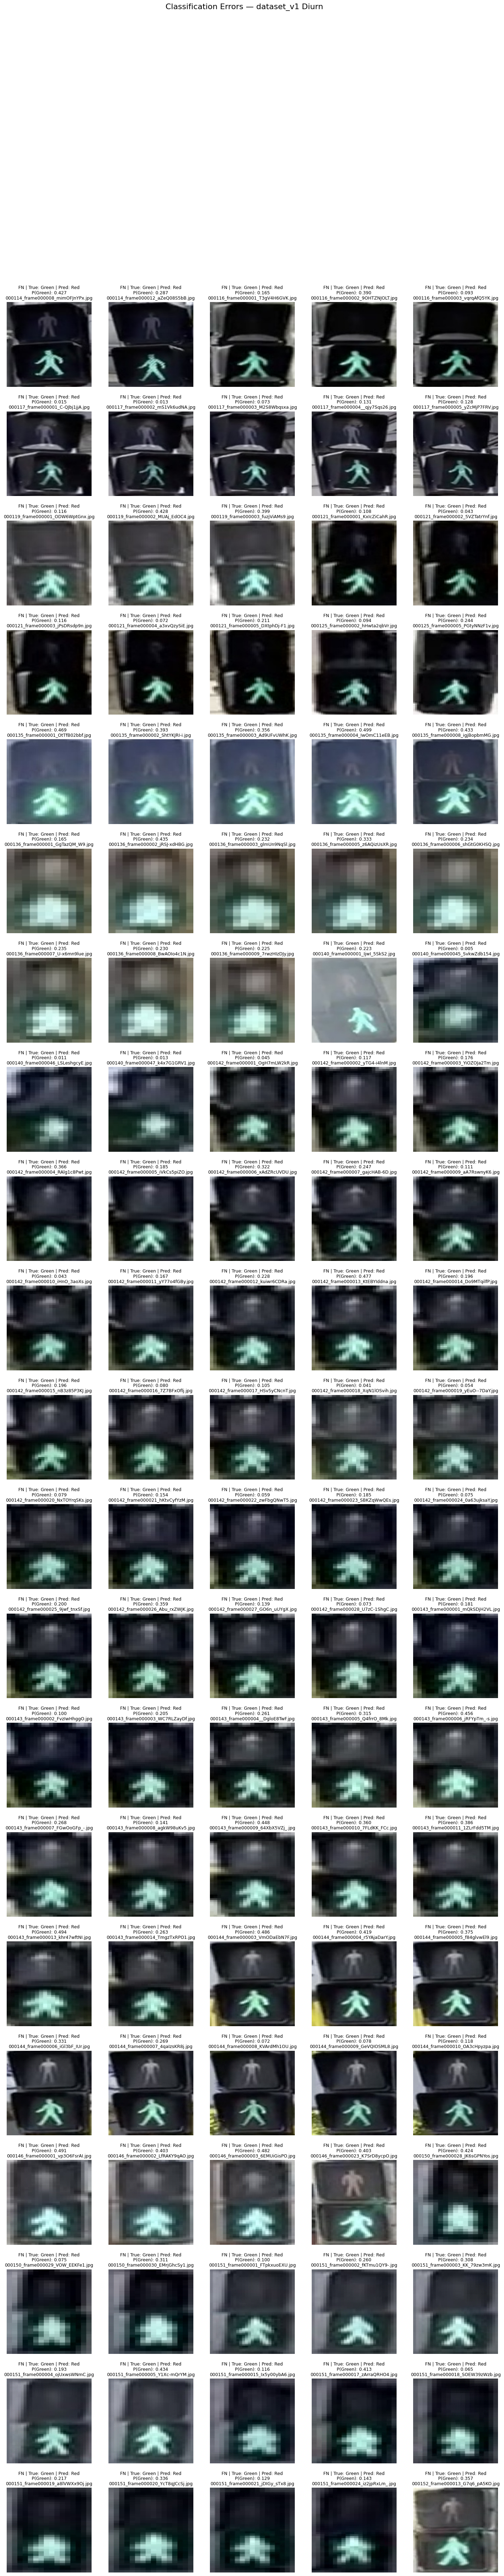

In [64]:
# ============================================================
# DIURN — PLOT ERRORS
# ============================================================

N_COLS = 5

n_images = len(df_errors_diurn)

n_rows = math.ceil(
    n_images / N_COLS
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=N_COLS,
    figsize=(18, 4 * n_rows),
)

axes = axes.flatten()


# ============================================================
# PLOT
# ============================================================

for ax, (_, row) in zip(
    axes,
    df_errors_diurn.iterrows(),
):

    image = Image.open(
        row["filepath"]
    )

    ax.imshow(
        image
    )

    ax.set_title(
        f"{row['error_type']} | "
        f"True: {row['true_class']} | "
        f"Pred: {row['predicted_class']}\n"
        f"P(Green): {row['probability_green']:.3f}\n"
        f"{row['filename']}",
        fontsize=9,
    )

    ax.axis(
        "off"
    )


# ============================================================
# HIDE UNUSED AXES
# ============================================================

for ax in axes[n_images:]:
    ax.axis(
        "off"
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Classification Errors — dataset_v1 Diurn",
    fontsize=16,
)


# ============================================================
# LAYOUT
# ============================================================


plt.show()

### Nocturn

In [65]:
# ============================================================
# NOCTURN — FILTER ERRORS
# ============================================================

df_v1_nocturn = pd.read_csv(
    RESULTS_DIR
    / "test"
    / "predictions_dataset_v1_nocturn.csv"
)

df_errors_nocturn = df_v1_nocturn[
    df_v1_nocturn["error_type"] != "correct"
].copy()

print(
    f"Nocturn errors: {len(df_errors_nocturn)}"
)

print(
    df_errors_nocturn["error_type"].value_counts()
)

Nocturn errors: 0
Series([], Name: count, dtype: int64)


In [66]:
# # ============================================================
# # NOCTURN — PLOT ERRORS
# # ============================================================

# N_COLS = 5

# n_images = len(df_errors_nocturn)

# n_rows = math.ceil(
#     n_images / N_COLS
# )


# # ============================================================
# # FIGURE
# # ============================================================

# fig, axes = plt.subplots(
#     nrows=n_rows,
#     ncols=N_COLS,
#     figsize=(18, 4 * n_rows),
# )

# axes = axes.flatten()


# # ============================================================
# # PLOT
# # ============================================================

# for ax, (_, row) in zip(
#     axes,
#     df_errors_nocturn.iterrows(),
# ):

#     image = Image.open(
#         row["filepath"]
#     )

#     ax.imshow(
#         image
#     )

#     ax.set_title(
#         f"{row['error_type']} | "
#         f"True: {row['true_class']} | "
#         f"Pred: {row['predicted_class']}\n"
#         f"P(Green): {row['probability_green']:.3f}\n"
#         f"{row['filename']}",
#         fontsize=9,
#     )

#     ax.axis(
#         "off"
#     )


# # ============================================================
# # HIDE UNUSED AXES
# # ============================================================

# for ax in axes[n_images:]:
#     ax.axis(
#         "off"
#     )


# # ============================================================
# # TITLE
# # ============================================================

# fig.suptitle(
#     "Classification Errors — dataset_v1 Nocturn",
#     fontsize=16,
# )


# # ============================================================
# # LAYOUT
# # ============================================================


# plt.show()

## Errores dataset_v2

### Diurn

In [67]:
df_v2_diurn = pd.read_csv(
    RESULTS_DIR
    / "test"
    / "predictions_dataset_v2_diurn.csv"
)

df_errors_diurn = df_v2_diurn[
    df_v2_diurn["error_type"] != "correct"
].copy()

print(
    f"Diurn errors: {len(df_errors_diurn)}"
)

print(
    df_errors_diurn["error_type"].value_counts()
)

Diurn errors: 6
error_type
FP    6
Name: count, dtype: int64


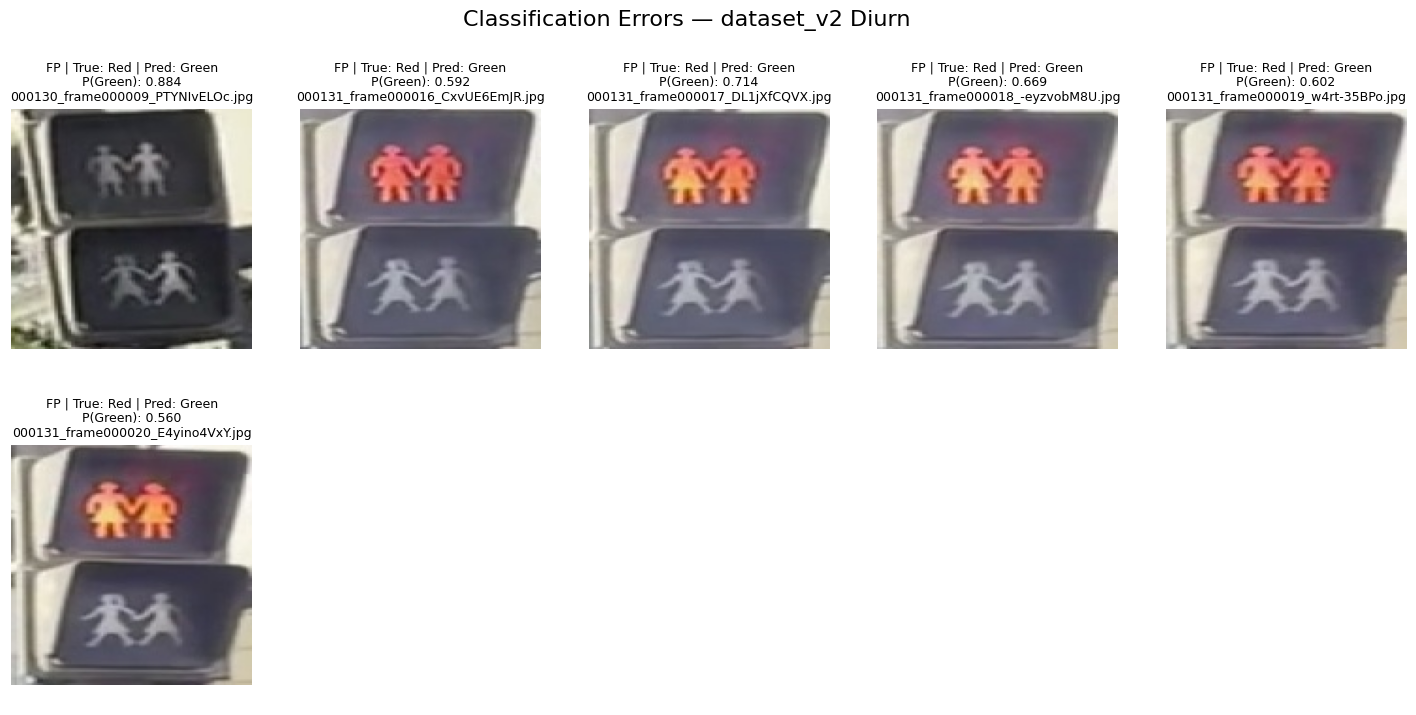

In [68]:
# ============================================================
# DIURN — PLOT ERRORS
# ============================================================

N_COLS = 5

n_images = len(df_errors_diurn)

n_rows = math.ceil(
    n_images / N_COLS
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=N_COLS,
    figsize=(18, 4 * n_rows),
)

axes = axes.flatten()


# ============================================================
# PLOT
# ============================================================

for ax, (_, row) in zip(
    axes,
    df_errors_diurn.iterrows(),
):

    image = Image.open(
        row["filepath"]
    )

    ax.imshow(
        image
    )

    ax.set_title(
        f"{row['error_type']} | "
        f"True: {row['true_class']} | "
        f"Pred: {row['predicted_class']}\n"
        f"P(Green): {row['probability_green']:.3f}\n"
        f"{row['filename']}",
        fontsize=9,
    )

    ax.axis(
        "off"
    )


# ============================================================
# HIDE UNUSED AXES
# ============================================================

for ax in axes[n_images:]:
    ax.axis(
        "off"
    )


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Classification Errors — dataset_v2 Diurn",
    fontsize=16,
)


# ============================================================
# LAYOUT
# ============================================================


plt.show()

### Nocturn

In [69]:
# ============================================================
# NOCTURN — FILTER ERRORS
# ============================================================

df_v2_nocturn = pd.read_csv(
    RESULTS_DIR
    / "test"
    / "predictions_dataset_v2_nocturn.csv"
)

df_errors_nocturn = df_v2_nocturn[
    df_v2_nocturn["error_type"] != "correct"
].copy()

print(
    f"Nocturn errors: {len(df_errors_nocturn)}"
)

print(
    df_errors_nocturn["error_type"].value_counts()
)

Nocturn errors: 0
Series([], Name: count, dtype: int64)


In [70]:
# # ============================================================
# # NOCTURN — PLOT ERRORS
# # ============================================================

# N_COLS = 5

# n_images = len(df_errors_nocturn)

# n_rows = math.ceil(
#     n_images / N_COLS
# )


# # ============================================================
# # FIGURE
# # ============================================================

# fig, axes = plt.subplots(
#     nrows=n_rows,
#     ncols=N_COLS,
#     figsize=(18, 4 * n_rows),
# )

# axes = axes.flatten()


# # ============================================================
# # PLOT
# # ============================================================

# for ax, (_, row) in zip(
#     axes,
#     df_errors_nocturn.iterrows(),
# ):

#     image = Image.open(
#         row["filepath"]
#     )

#     ax.imshow(
#         image
#     )

#     ax.set_title(
#         f"{row['error_type']} | "
#         f"True: {row['true_class']} | "
#         f"Pred: {row['predicted_class']}\n"
#         f"P(Green): {row['probability_green']:.3f}\n"
#         f"{row['filename']}",
#         fontsize=9,
#     )

#     ax.axis(
#         "off"
#     )


# # ============================================================
# # HIDE UNUSED AXES
# # ============================================================

# for ax in axes[n_images:]:
#     ax.axis(
#         "off"
#     )


# # ============================================================
# # TITLE
# # ============================================================

# fig.suptitle(
#     "Classification Errors — dataset_v1 Nocturn",
#     fontsize=16,
# )


# # ============================================================
# # LAYOUT
# # ============================================================


# plt.show()

## Análisis de distribuciones por clase

V1 Diurn
Total errors: 105

Error types:
error_type
FN    105
Name: count, dtype: int64

Probability statistics:
count    105.000000
mean       0.230587
std        0.143935
min        0.005271
25%        0.107510
50%        0.210855
75%        0.358876
max        0.498630
Name: probability_green, dtype: float64

Distance to threshold:
count    105.000000
mean       0.269413
std        0.143935
min        0.001370
25%        0.141124
50%        0.289145
75%        0.392490
max        0.494729
Name: distance_to_threshold, dtype: float64

V2 Diurn
Total errors: 6

Error types:
error_type
FP    6
Name: count, dtype: int64

Probability statistics:
count    6.000000
mean     0.670082
std      0.118998
min      0.559664
25%      0.594267
50%      0.635540
75%      0.702534
max      0.884372
Name: probability_green, dtype: float64

Distance to threshold:
count    6.000000
mean     0.170082
std      0.118998
min      0.059664
25%      0.094267
50%      0.135540
75%      0.202534
max      0.3843

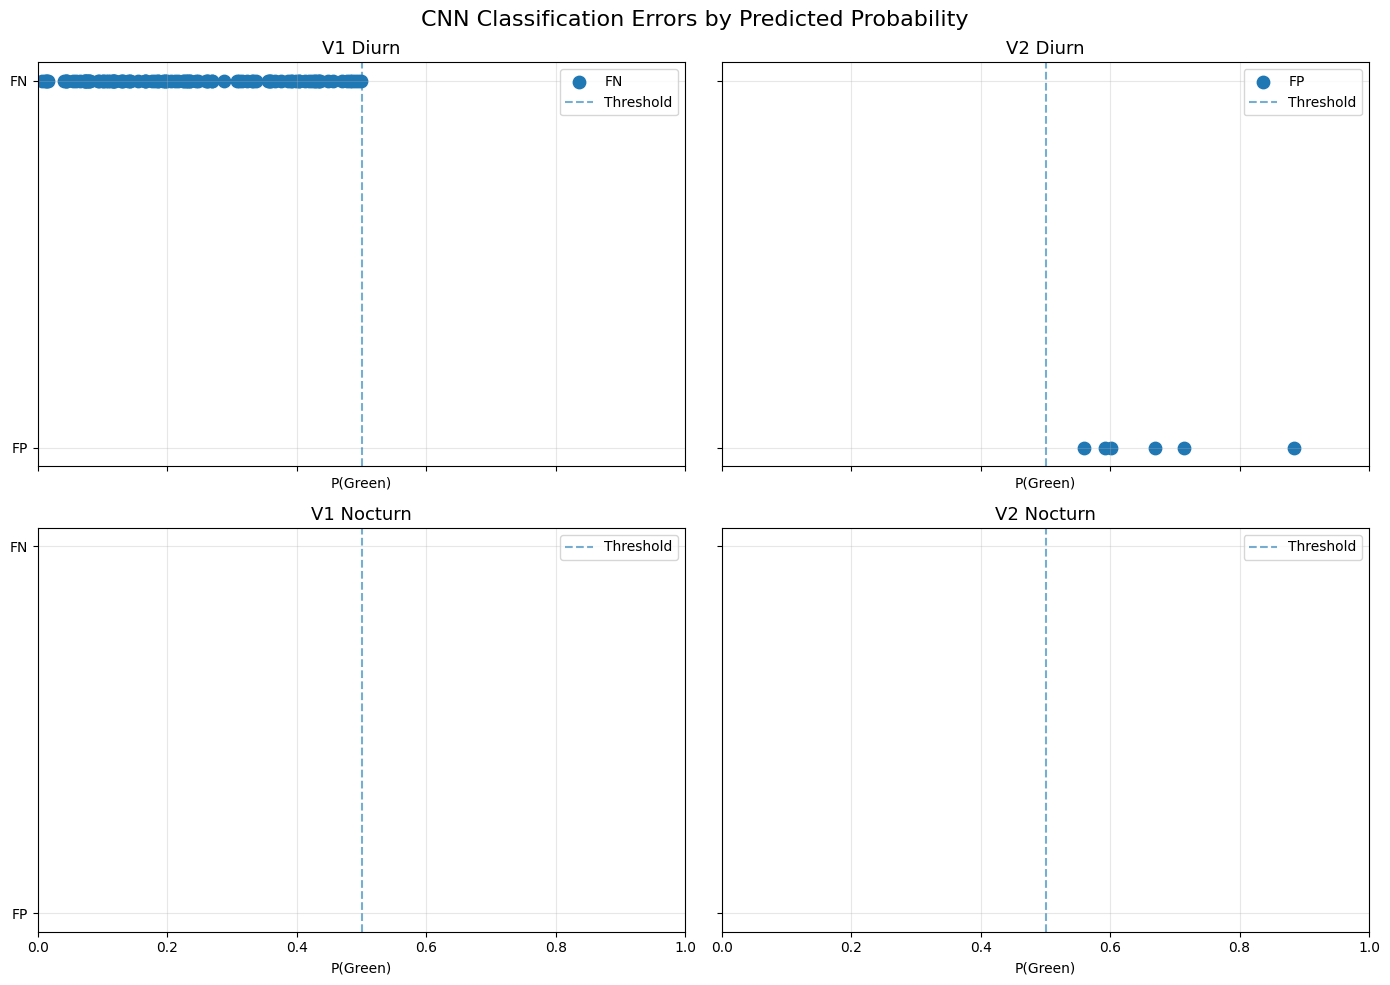

In [71]:
# ============================================================
# CONFIGURATION
# ============================================================

datasets = {
    "V1 Diurn": df_v1_diurn,
    "V2 Diurn": df_v2_diurn,
    "V1 Nocturn": df_v1_nocturn,
    "V2 Nocturn": df_v2_nocturn,
}

THRESHOLD = 0.5


# ============================================================
# PREPARE ERRORS
# ============================================================

error_dfs = {}

for name, df in datasets.items():

    errors = df[
        df["error_type"] != "correct"
    ].copy()

    errors["distance_to_threshold"] = (
        errors["probability_green"] - THRESHOLD
    ).abs()

    error_dfs[name] = errors


# ============================================================
# SUMMARY
# ============================================================

for name, df_errors in error_dfs.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        f"Total errors: {len(df_errors)}"
    )

    if len(df_errors) == 0:
        print()
        continue

    print(
        "\nError types:"
    )

    print(
        df_errors["error_type"].value_counts()
    )

    print(
        "\nProbability statistics:"
    )

    print(
        df_errors["probability_green"].describe()
    )

    print(
        "\nDistance to threshold:"
    )

    print(
        df_errors["distance_to_threshold"].describe()
    )

    print()


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()


for ax, (name, df_errors) in zip(
    axes,
    error_dfs.items(),
):

    # --------------------------------------------------------
    # FP
    # --------------------------------------------------------

    fp = df_errors[
        df_errors["error_type"] == "FP"
    ]

    # --------------------------------------------------------
    # FN
    # --------------------------------------------------------

    fn = df_errors[
        df_errors["error_type"] == "FN"
    ]

    # --------------------------------------------------------
    # Plot FP
    # --------------------------------------------------------

    if len(fp) > 0:

        ax.scatter(
            fp["probability_green"],
            [0] * len(fp),
            label="FP",
            s=80,
        )

    # --------------------------------------------------------
    # Plot FN
    # --------------------------------------------------------

    if len(fn) > 0:

        ax.scatter(
            fn["probability_green"],
            [1] * len(fn),
            label="FN",
            s=80,
        )

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    ax.axvline(
        THRESHOLD,
        linestyle="--",
        alpha=0.6,
        label="Threshold",
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        name,
        fontsize=13,
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_yticklabels(
        ["FP", "FN"]
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "CNN Classification Errors by Predicted Probability",
    fontsize=16,
)

plt.tight_layout()

plt.show()

V1 common Youden threshold: 0.0408
V2 common Youden threshold: 0.8768


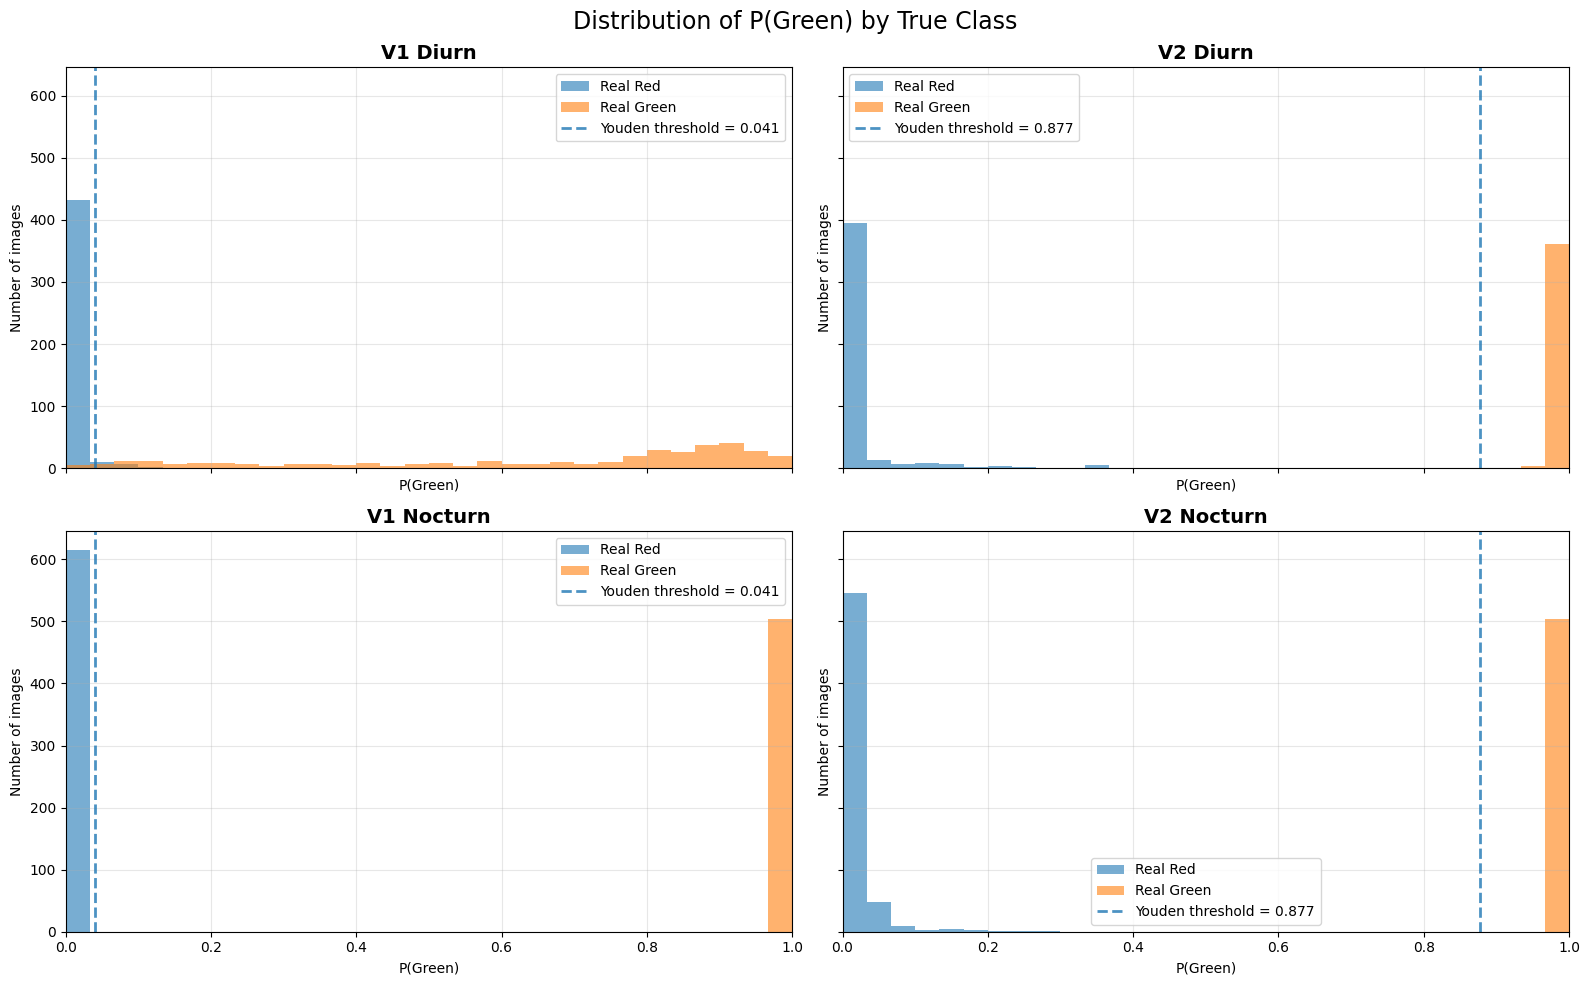

In [72]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve


# ============================================================
# CONFIGURATION
# ============================================================

datasets = {
    "V1 Diurn": df_v1_diurn,
    "V2 Diurn": df_v2_diurn,
    "V1 Nocturn": df_v1_nocturn,
    "V2 Nocturn": df_v2_nocturn,
}


# ============================================================
# CALCULATE COMMON YOUDEN THRESHOLD
#
# Un único threshold por modelo utilizando conjuntamente
# los datos diurnos y nocturnos.
# ============================================================

thresholds = {}


for version in ["V1", "V2"]:

    if version == "V1":

        df_combined = pd.concat(
            [
                df_v1_diurn,
                df_v1_nocturn,
            ],
            ignore_index=True,
        )

    else:

        df_combined = pd.concat(
            [
                df_v2_diurn,
                df_v2_nocturn,
            ],
            ignore_index=True,
        )

    # --------------------------------------------------------
    # True labels
    #
    # Red   -> 0
    # Green -> 1
    # --------------------------------------------------------

    y_true = (
        df_combined["true_label"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # Model output
    #
    # P(Green)
    # --------------------------------------------------------

    y_scores = (
        df_combined["probability_green"]
        .to_numpy()
    )

    # --------------------------------------------------------
    # ROC
    # --------------------------------------------------------

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_scores,
    )

    # --------------------------------------------------------
    # Remove infinite threshold
    # --------------------------------------------------------

    valid = np.isfinite(
        roc_thresholds
    )

    fpr = fpr[valid]
    tpr = tpr[valid]
    roc_thresholds = roc_thresholds[valid]

    # --------------------------------------------------------
    # Youden's J
    #
    # J = TPR - FPR
    # --------------------------------------------------------

    youden = (
        tpr - fpr
    )

    best_index = np.argmax(
        youden
    )

    best_threshold = float(
        roc_thresholds[best_index]
    )

    thresholds[version] = (
        best_threshold
    )

    print(
        f"{version} common Youden threshold: "
        f"{best_threshold:.4f}"
    )


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
    sharey=True,
)


# ============================================================
# PLOTS
# ============================================================

for ax, (name, df) in zip(
    axes.flatten(),
    datasets.items(),
):

    # --------------------------------------------------------
    # Dataset version
    # --------------------------------------------------------

    version = name.split()[0]

    threshold = thresholds[
        version
    ]

    # --------------------------------------------------------
    # Real Red
    # --------------------------------------------------------

    red = df.loc[
        df["true_class"] == "Red",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Real Green
    # --------------------------------------------------------

    green = df.loc[
        df["true_class"] == "Green",
        "probability_green",
    ]

    # --------------------------------------------------------
    # Histograms
    # --------------------------------------------------------

    ax.hist(
        red,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Red",
    )

    ax.hist(
        green,
        bins=30,
        range=(0, 1),
        alpha=0.6,
        label="Real Green",
    )

    # --------------------------------------------------------
    # Common Youden threshold
    # --------------------------------------------------------

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=(
            f"Youden threshold = "
            f"{threshold:.3f}"
        ),
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        name,
        fontsize=14,
        fontweight="bold",
    )

    ax.set_xlabel(
        "P(Green)"
    )

    ax.set_ylabel(
        "Number of images"
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Distribution of P(Green) by True Class",
    fontsize=17,
)


# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()

Se observa que las probabilidades predichas por los modelos siguen distribuciones completamente diferentes. Para el primero, tenemos rojos con probabilidades de verde muy bajos mientras que las probabilidades de los verdes están mucho más dispersas. Existen, de hecho, solapamientos en probabilidades bajas.

Sin embargo, para el v2, las probabilidades de rojos y verdes están mucho más separadas. Si el semáforo es rojo, P(verde) tiende a valores muy bajos mientras que si el semáforo es verde, P(verde) tiende a ser muy alto.

De noche parece que estas diferencias están más marcadas en v1 pero también son excelentes en v2.

Lo más importante para comparar los modelos es que requieren puntos de threshold completamente diferentes ya que sus puntos de Youden son muy distintos.